# Experimento 1

In [26]:
import sys, os, duckdb
import pandas as pd

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
from config.config import V2_DB

con = duckdb.connect(V2_DB)

VARS_DESCARTADAS = (
    'CLOUD_BT', 'CLOUD_BT_MAX', 'CLOUD_BT_MIN',
    'CLOUD_TT', 'CLOUD_TT_MAX', 'CLOUD_TT_MIN',
    'GWM_HEIGHT', 'GWM_HEIGHT_ANOMALY',
    'IMERG_PRECLIQUID_PROB', 'IMERG_PRECTOT', 'IMERG_PRECTOT_COUNT',
    'LWLAND', 'ORIGINAL_ALLSKY_SFC_LW_DWN', 'ORIGINAL_ALLSKY_SFC_SW_DWN',
    'ORIGINAL_CLRSKY_SFC_LW_DWN', 'ORIGINAL_CLRSKY_SFC_SW_DWN',
    'PRMC', 'PRMC_PRCNTL', 'RZMC', 'RZMC_PRCNTL',
    'SFMC', 'SWLAND', 'SZA'
)
vars_excluidas_sql = ", ".join([f"'{v}'" for v in VARS_DESCARTADAS])

vars_clima = con.execute(f"""
    SELECT DISTINCT id_variable
    FROM working.climatologia
    WHERE id_variable NOT IN ({vars_excluidas_sql})
    ORDER BY id_variable
""").df()['id_variable'].tolist()

pivot_cols = ",\n    ".join([
    f"AVG(CASE WHEN id_variable = '{v}' THEN resultado_numerico END) AS \"{v}\""
    for v in vars_clima
])

df = con.execute(f"""
    WITH clima_pivot AS (
        SELECT
            id_clave_inc,
            {pivot_cols}
        FROM working.climatologia
        WHERE id_variable NOT IN ({vars_excluidas_sql})
        GROUP BY id_clave_inc
    ),
    demo_total AS (
        SELECT
            id_cvegeo,
            anio,
            SUM(pob_total) AS pob_total
        FROM working.demografia
        GROUP BY id_cvegeo, anio
    )
    SELECT
        i.id_clave_inc,
        i.latitud,
        i.longitud,
        i.anio,
        EXTRACT(MONTH FROM i.fecha_inicio)::INTEGER AS mes,
        EXTRACT(DOW   FROM i.fecha_inicio)::INTEGER AS dia_semana,
        i.tipo_de_incendio,
        v.tipo_de_vegetacion,
        v.regimen_del_fuego,
        m.nombre_municipio,
        o.hora_deteccion,
        dem.pob_total,
        d.tamanio,
        cp.*
    FROM working.incendios i
    LEFT JOIN working.vegetacion   v   ON i.id_vegetacion = v.id_vegetacion
    LEFT JOIN working.municipios   m   ON i.id_cvegeo     = m.id_cvegeo
    LEFT JOIN working.operaciones  o   ON i.id_clave_inc  = o.id_clave_inc
    LEFT JOIN working.danos        d   ON i.id_clave_inc  = d.id_clave_inc
    LEFT JOIN demo_total           dem ON i.id_cvegeo     = dem.id_cvegeo
                                      AND i.anio          = dem.anio
    LEFT JOIN clima_pivot          cp  ON i.id_clave_inc  = cp.id_clave_inc
""").df()

con.close()

df = df.loc[:, ~df.columns.duplicated()]

# Convertir hora_deteccion a minutos desde medianoche
df['hora_deteccion'] = pd.to_datetime(df['hora_deteccion'].astype(str), errors='coerce')
df['hora_deteccion_min'] = (
    df['hora_deteccion'].dt.hour * 60 +
    df['hora_deteccion'].dt.minute
)
df = df.drop(columns=['hora_deteccion'])

print("Pivoteo listo.")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Pivoteo listo.


/tmp/ipykernel_6331/2456706728.py:82: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['hora_deteccion'] = pd.to_datetime(df['hora_deteccion'].astype(str), errors='coerce')


In [27]:
pd.set_option('display.max_columns', None)
print(df.head())


  id_clave_inc    latitud    longitud  anio  mes  dia_semana tipo_de_incendio  \
0   17-15-1416  19.473797 -100.141563  2017    5           4      superficial   
1   17-15-1435  19.073196  -99.684868  2017    6           6      superficial   
2   17-15-1438  19.748848  -99.757736  2017    6           0      superficial   
3   17-15-1448  19.421167  -98.729469  2017    6           5      superficial   
4   17-15-1447  18.896444  -99.499107  2017    6           5      superficial   

      tipo_de_vegetacion regimen_del_fuego   nombre_municipio  pob_total  \
0  bosque de pino-encino          adaptado     villa victoria   108388.0   
1       bosque de oyamel          sensible  tenango del valle    90034.0   
2  bosque de pino-encino          adaptado        atlacomulco   106672.0   
3         bosque de pino          adaptado            texcoco   262003.0   
4      bosque de tascate          sensible          malinalco    28356.0   

           tamanio id_clave_inc_1  AIRMASS  ALLSKY_KT  A

In [28]:
# Eliminar columna duplicada
df = df.drop(columns=['id_clave_inc_1'], errors='ignore')

# Mapear target
mapa_tamanio = {
    '0 a 5 hectareas'       : '1_0_a_5',
    '6 a 10 hectareas'      : '2_6_a_20',
    '11 a 20 hectareas'     : '2_6_a_20',
    '21 a 50 hectareas'     : '3_21_a_50',
    '51 a 100 hectareas'    : '4_mas_de_50',
    'mayor a 100 hectareas' : '4_mas_de_50',
}
df['tamanio_modelo'] = df['tamanio'].map(mapa_tamanio)
df = df.drop(columns=['tamanio'])

print("Pivoteo listo.")

Pivoteo listo.


In [29]:
# ================================================================
# INSPECCIÓN — nulos y duplicados
# ================================================================
# Duplicados
print(f"Filas duplicadas : {df.duplicated().sum()}")
print(f"IDs duplicados   : {df['id_clave_inc'].duplicated().sum()}")

# Nulos por columna
nulos = df.isnull().sum()
nulos = nulos[nulos > 0].sort_values(ascending=False)
print(f"\nColumnas con nulos ({len(nulos)} de {df.shape[1]}):")
print(nulos.to_string())

# Nulos por fila
nulos_por_fila = df.isnull().sum(axis=1)
print(f"\nFilas con al menos 1 nulo : {(nulos_por_fila > 0).sum()}")
print(f"Filas con más de 5 nulos  : {(nulos_por_fila > 5).sum()}")
print(f"Filas con más de 10 nulos : {(nulos_por_fila > 10).sum()}")

print("\nInspección lista.")

Filas duplicadas : 0
IDs duplicados   : 0

Columnas con nulos (19 de 135):
latitud               174
longitud              174
EVLAND                105
TSOIL5                105
EVPTRNS               105
FRSNO                 105
GWETPROF              105
GWETROOT              105
PRECSNOLAND           105
SNODP                 105
TSOIL1                105
TSURF                 105
TSOIL2                105
TSOIL3                105
TSOIL4                105
TSOIL6                105
CLRSKY_NKT             33
hora_deteccion_min      3
NDMI                    2

Filas con al menos 1 nulo : 212
Filas con más de 5 nulos  : 105
Filas con más de 10 nulos : 105

Inspección lista.


In [30]:
mask_suelo  = df['TSOIL1'].isnull()
mask_coords = df['latitud'].isnull()

print(f"Filas con nulos de suelo Y sin coordenadas: {(mask_suelo & mask_coords).sum()}")

print("\nAños — nulos de suelo:")
print(df[mask_suelo]['anio'].value_counts().sort_index())

print("\nAños — sin coordenadas:")
print(df[mask_coords]['anio'].value_counts().sort_index())

print("\nTarget — nulos de suelo:")
print(df[mask_suelo]['tamanio_modelo'].value_counts())

print("\nTarget — sin coordenadas:")
print(df[mask_coords]['tamanio_modelo'].value_counts())

print("\nDiagnóstico listo.")

Filas con nulos de suelo Y sin coordenadas: 105

Años — nulos de suelo:
anio
2015    36
2016    69
Name: count, dtype: int64

Años — sin coordenadas:
anio
2015    38
2016    80
2017     8
2018    10
2019     1
2020    11
2021     3
2022     7
2023     7
2024     7
2025     2
Name: count, dtype: int64

Target — nulos de suelo:
tamanio_modelo
1_0_a_5        88
2_6_a_20       13
4_mas_de_50     3
3_21_a_50       1
Name: count, dtype: int64

Target — sin coordenadas:
tamanio_modelo
1_0_a_5        110
2_6_a_20        35
4_mas_de_50     21
3_21_a_50        8
Name: count, dtype: int64

Diagnóstico listo.


In [31]:
total        = len(df)
a_eliminar   = df['latitud'].isnull().sum()
quedan       = total - a_eliminar
print(f"Total          : {total}")
print(f"A eliminar     : {a_eliminar}")
print(f"Quedan         : {quedan}  ({quedan/total*100:.1f}%)")

Total          : 12703
A eliminar     : 174
Quedan         : 12529  (98.6%)


In [32]:
# ================================================================
# LIMPIEZA — eliminación de filas con nulos críticos
# ================================================================

# Eliminar filas sin coordenadas (incluye las 105 de suelo)
df = df[df['latitud'].notnull()].copy()

# Imputar nulos menores con mediana
for col in ['CLRSKY_NKT', 'hora_deteccion_min', 'NDMI']:
    df[col] = df[col].fillna(df[col].median())

# Verificación
nulos_restantes = df.isnull().sum().sum()
print(f"Shape final     : {df.shape}")
print(f"Nulos restantes : {nulos_restantes}")

print("\nLimpieza lista.")

Shape final     : (12529, 135)
Nulos restantes : 0

Limpieza lista.


In [33]:

cols_categoricas = ['tipo_de_incendio', 'tipo_de_vegetacion', 
                    'regimen_del_fuego', 'nombre_municipio']

for col in cols_categoricas:
    df[col] = df[col].str.strip()
    df[col] = df[col].str.replace('\n', ' ')
    df[col] = df[col].str.replace('\t', ' ')
    df[col] = df[col].str.replace(r'\s+', ' ', regex=True)

# Unificar categorías equivalentes
df['tipo_de_vegetacion'] = df['tipo_de_vegetacion'].str.replace(
    'bosque de encino-pino', 'bosque de pino-encino'
)

# Verificación
print(df['tipo_de_vegetacion'].value_counts().to_string())
print("\nLimpieza de categóricas lista.")

tipo_de_vegetacion
bosque de pino                                              4669
bosque de pino-encino                                       4040
bosque de encino                                            2141
bosque de oyamel                                             927
matorral crasicaule                                          299
bosque mesofilo de montana                                   165
bosque cultivado                                              79
bosque de tascate                                             62
bosque de cedro                                               57
selva baja caducifolia                                        51
pradera de alta montana                                       18
bosque inducido                                                6
pastizal natural                                               4
pastizal halofilo                                              3
matorral submontano                                            2
tular 

In [34]:
cols_categoricas = ['tipo_de_incendio', 'tipo_de_vegetacion', 'regimen_del_fuego', 'nombre_municipio']

for col in cols_categoricas:
    print(f"\n{col}:")
    print(df[col].value_counts().to_string())


tipo_de_incendio:
tipo_de_incendio
superficial    12435
mixto             74
de copa           18
subterraneo        2

tipo_de_vegetacion:
tipo_de_vegetacion
bosque de pino                                              4669
bosque de pino-encino                                       4040
bosque de encino                                            2141
bosque de oyamel                                             927
matorral crasicaule                                          299
bosque mesofilo de montana                                   165
bosque cultivado                                              79
bosque de tascate                                             62
bosque de cedro                                               57
selva baja caducifolia                                        51
pradera de alta montana                                       18
bosque inducido                                                6
pastizal natural                                            

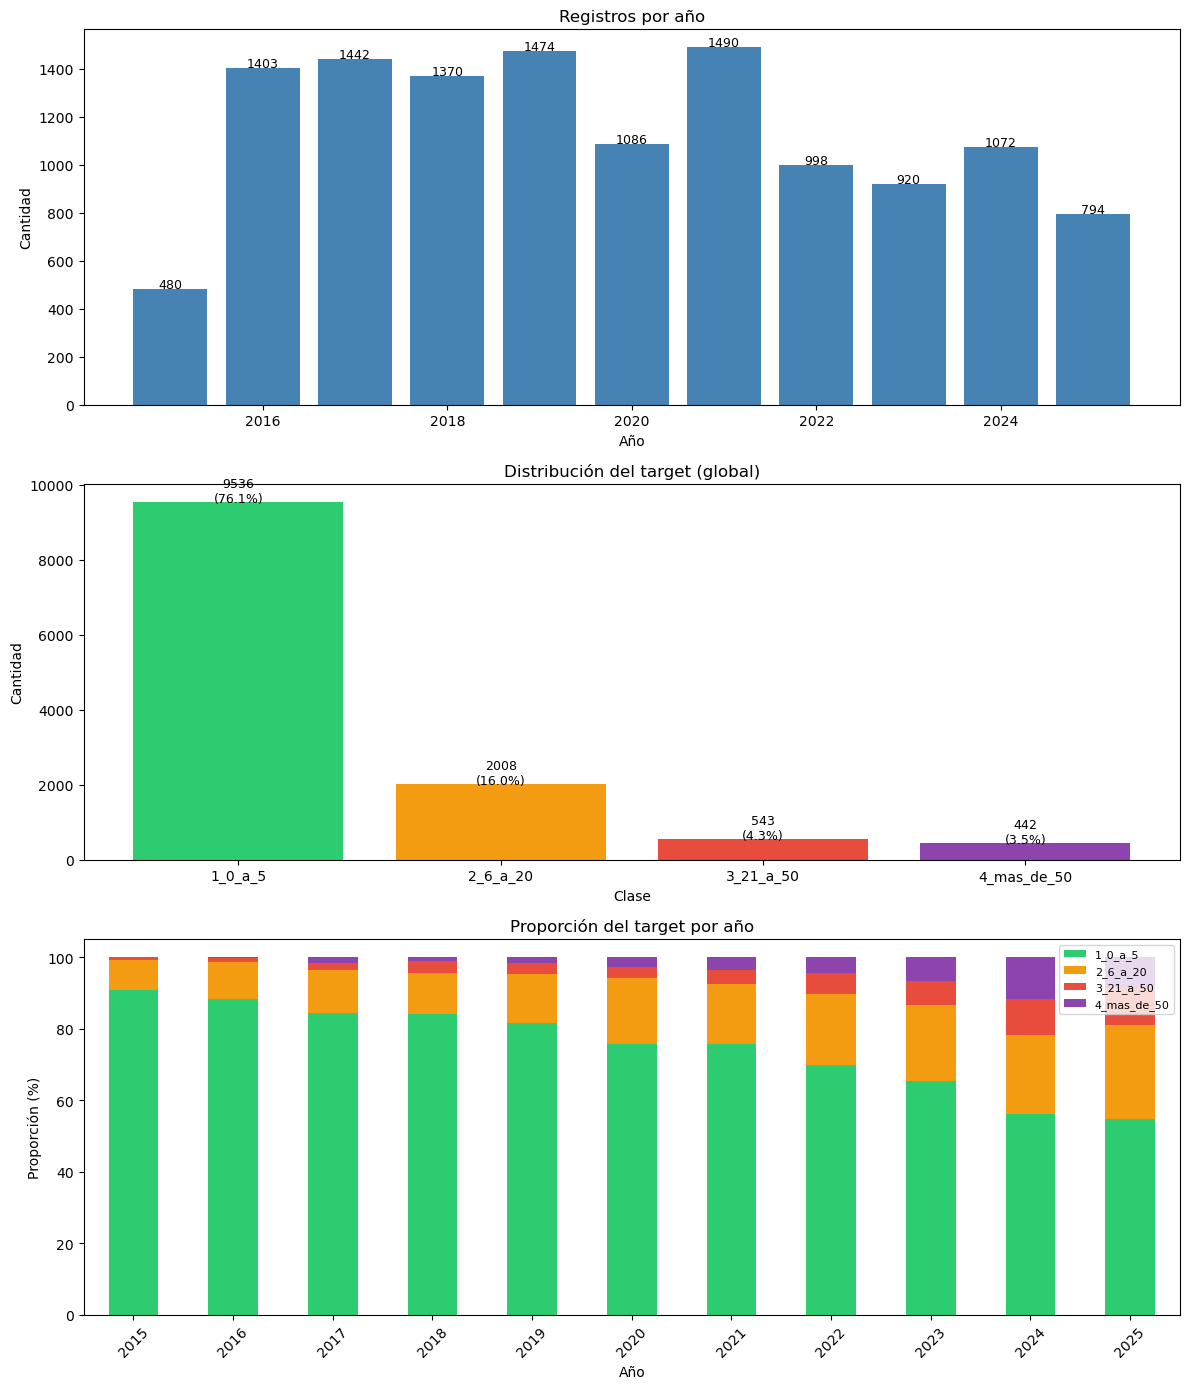

Gráfica guardada.


In [35]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(12, 14))

# --- Gráfica 1: Registros por año ---
conteo_anio = df.groupby('anio').size()
axes[0].bar(conteo_anio.index, conteo_anio.values, color='steelblue')
axes[0].set_title('Registros por año')
axes[0].set_xlabel('Año')
axes[0].set_ylabel('Cantidad')
for i, (anio, val) in enumerate(conteo_anio.items()):
    axes[0].text(anio, val + 5, str(val), ha='center', fontsize=9)

# --- Gráfica 2: Distribución del target global ---
dist = df['tamanio_modelo'].value_counts().sort_index()
colores = ['#2ecc71', '#f39c12', '#e74c3c', '#8e44ad']
axes[1].bar(dist.index, dist.values, color=colores)
axes[1].set_title('Distribución del target (global)')
axes[1].set_xlabel('Clase')
axes[1].set_ylabel('Cantidad')
for i, (clase, val) in enumerate(dist.items()):
    axes[1].text(i, val + 10, f'{val}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=9)

# --- Gráfica 3: Target por año (proporciones) ---
target_anio = df.groupby(['anio', 'tamanio_modelo']).size().unstack(fill_value=0)
target_anio_pct = target_anio.div(target_anio.sum(axis=1), axis=0) * 100
target_anio_pct.plot(kind='bar', stacked=True, ax=axes[2], color=colores)
axes[2].set_title('Proporción del target por año')
axes[2].set_xlabel('Año')
axes[2].set_ylabel('Proporción (%)')
axes[2].legend(loc='upper right', fontsize=8)
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('eda_target.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfica guardada.")


Para el split mi recomendación sería:

Train: 2015 — 2022 (~10,000 registros)
Validation: 2023 (~998 registros)
Test: 2024 — 2025 (~1,866 registros)

In [36]:
# ================================================================
# SPLIT TEMPORAL
# ================================================================

train = df[df['anio'] <= 2022].copy()
val   = df[df['anio'] == 2023].copy()
test  = df[df['anio'] >= 2024].copy()

# Verificación
print(f"Train : {len(train):>5} registros  ({train['anio'].min()}-{train['anio'].max()})")
print(f"Val   : {len(val):>5} registros  ({val['anio'].min()}-{val['anio'].max()})")
print(f"Test  : {len(test):>5} registros  ({test['anio'].min()}-{test['anio'].max()})")

print(f"\nProporción train : {len(train)/len(df)*100:.1f}%")
print(f"Proporción val   : {len(val)/len(df)*100:.1f}%")
print(f"Proporción test  : {len(test)/len(df)*100:.1f}%")

# Distribución del target en cada split
for nombre, split in [('Train', train), ('Val', val), ('Test', test)]:
    print(f"\nTarget — {nombre}:")
    dist = split['tamanio_modelo'].value_counts().sort_index()
    for clase, cnt in dist.items():
        print(f"   {clase:<20} {cnt:>4}  ({cnt/len(split)*100:.1f}%)")

print("\nSplit listo.")

Train :  9743 registros  (2015-2022)
Val   :   920 registros  (2023-2023)
Test  :  1866 registros  (2024-2025)

Proporción train : 77.8%
Proporción val   : 7.3%
Proporción test  : 14.9%

Target — Train:
   1_0_a_5              7897  (81.1%)
   2_6_a_20             1367  (14.0%)
   3_21_a_50             292  (3.0%)
   4_mas_de_50           187  (1.9%)

Target — Val:
   1_0_a_5               602  (65.4%)
   2_6_a_20              196  (21.3%)
   3_21_a_50              61  (6.6%)
   4_mas_de_50            61  (6.6%)

Target — Test:
   1_0_a_5              1037  (55.6%)
   2_6_a_20              445  (23.8%)
   3_21_a_50             190  (10.2%)
   4_mas_de_50           194  (10.4%)

Split listo.


In [37]:
# ================================================================
# SPLIT TEMPORAL
# ================================================================

train = df[df['anio'] <= 2022].copy()
val   = df[df['anio'] == 2023].copy()
test  = df[df['anio'] >= 2024].copy()

# Verificación
print(f"Train : {len(train):>5} registros  ({train['anio'].min()}-{train['anio'].max()})")
print(f"Val   : {len(val):>5} registros  ({val['anio'].min()}-{val['anio'].max()})")
print(f"Test  : {len(test):>5} registros  ({test['anio'].min()}-{test['anio'].max()})")
print("\nSplit listo.")

Train :  9743 registros  (2015-2022)
Val   :   920 registros  (2023-2023)
Test  :  1866 registros  (2024-2025)

Split listo.


Precaución: 3 variables constantes descartadas.
Climáticas procesadas  : 119
Grupos encontrados     : 33
Variables eliminadas   : 86


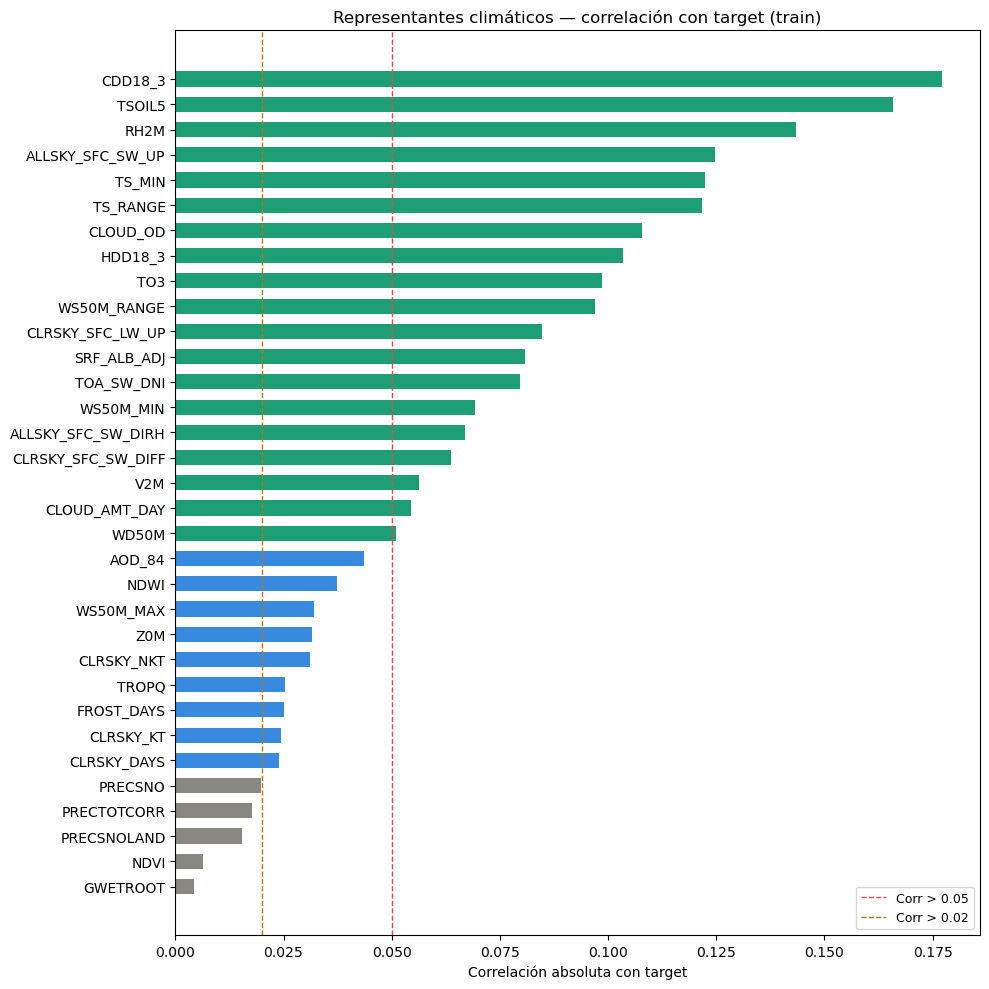


Pearson listo.


In [38]:
from scipy.cluster import hierarchy
from scipy.spatial.distance import pdist
from sklearn.preprocessing import OrdinalEncoder
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ================================================================
# PEARSON — CLUSTERING DE CORRELACIÓN (solo sobre train)
# ================================================================

TARGET_COL   = 'tamanio_modelo'
cols_clima   = [c for c in train.columns if c in vars_clima]

# Encoding ordinal del target
orden_clases = [['1_0_a_5', '2_6_a_20', '3_21_a_50', '4_mas_de_50']]
enc_target   = OrdinalEncoder(categories=orden_clases)
y_ord        = enc_target.fit_transform(train[[TARGET_COL]]).ravel()

# Preparar matriz climática solo del train
df_clima = train[cols_clima].copy()
df_clima = df_clima.dropna(axis=1, how='all')
df_clima = df_clima.fillna(df_clima.median())

desviacion   = df_clima.std()
cols_validas = desviacion[desviacion > 0].index
if len(cols_validas) < len(df_clima.columns):
    eliminadas = len(df_clima.columns) - len(cols_validas)
    print(f"Precaución: {eliminadas} variables constantes descartadas.")
df_clima = df_clima[cols_validas]

# Clustering jerárquico
dist_condensada = pdist(df_clima.values.T, metric='correlation')
dist_condensada = np.nan_to_num(dist_condensada, nan=0.0, posinf=1.0, neginf=-1.0)
dist_condensada = np.clip(dist_condensada, 0, None)

linkage        = hierarchy.ward(dist_condensada)
cluster_labels = hierarchy.fcluster(linkage, t=0.5, criterion='distance')

grupos_df = pd.DataFrame({
    'variable': df_clima.columns,
    'grupo'   : cluster_labels
})

representantes = []
log_grupos     = []

for g in sorted(grupos_df['grupo'].unique()):
    vars_grupo  = grupos_df[grupos_df['grupo'] == g]['variable'].tolist()
    corr_target = {}
    for v in vars_grupo:
        try:
            corr_val = abs(np.corrcoef(df_clima[v], y_ord)[0, 1])
            corr_target[v] = corr_val if not np.isnan(corr_val) else 0.0
        except:
            corr_target[v] = 0.0

    mejor = max(corr_target, key=corr_target.get)
    representantes.append(mejor)
    log_grupos.append({
        'grupo'        : g,
        'n_vars'       : len(vars_grupo),
        'representante': mejor,
        'corr_target'  : round(corr_target[mejor], 4),
        'descartadas'  : ', '.join([v for v in vars_grupo if v != mejor])
    })

df_log = (pd.DataFrame(log_grupos)
            .sort_values('corr_target', ascending=False)
            .reset_index(drop=True))

cols_clima_reducidas = representantes.copy()

print(f"Climáticas procesadas  : {len(df_clima.columns)}")
print(f"Grupos encontrados     : {len(representantes)}")
print(f"Variables eliminadas   : {len(df_clima.columns) - len(representantes)}")

# ================================================================
# GRÁFICA
# ================================================================
colores = [
    '#1D9E75' if v > 0.05 else '#378ADD' if v > 0.02 else '#888780'
    for v in df_log['corr_target']
]
fig, ax = plt.subplots(figsize=(10, 10))
ax.barh(df_log['representante'][::-1], df_log['corr_target'][::-1],
        color=colores[::-1], height=0.6)
ax.set_title('Representantes climáticos — correlación con target (train)')
ax.set_xlabel('Correlación absoluta con target')
ax.axvline(x=0.05, color='#E24B4A', linestyle='--', linewidth=1, label='Corr > 0.05')
ax.axvline(x=0.02, color='#BA7517', linestyle='--', linewidth=1, label='Corr > 0.02')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("\nPearson listo.")

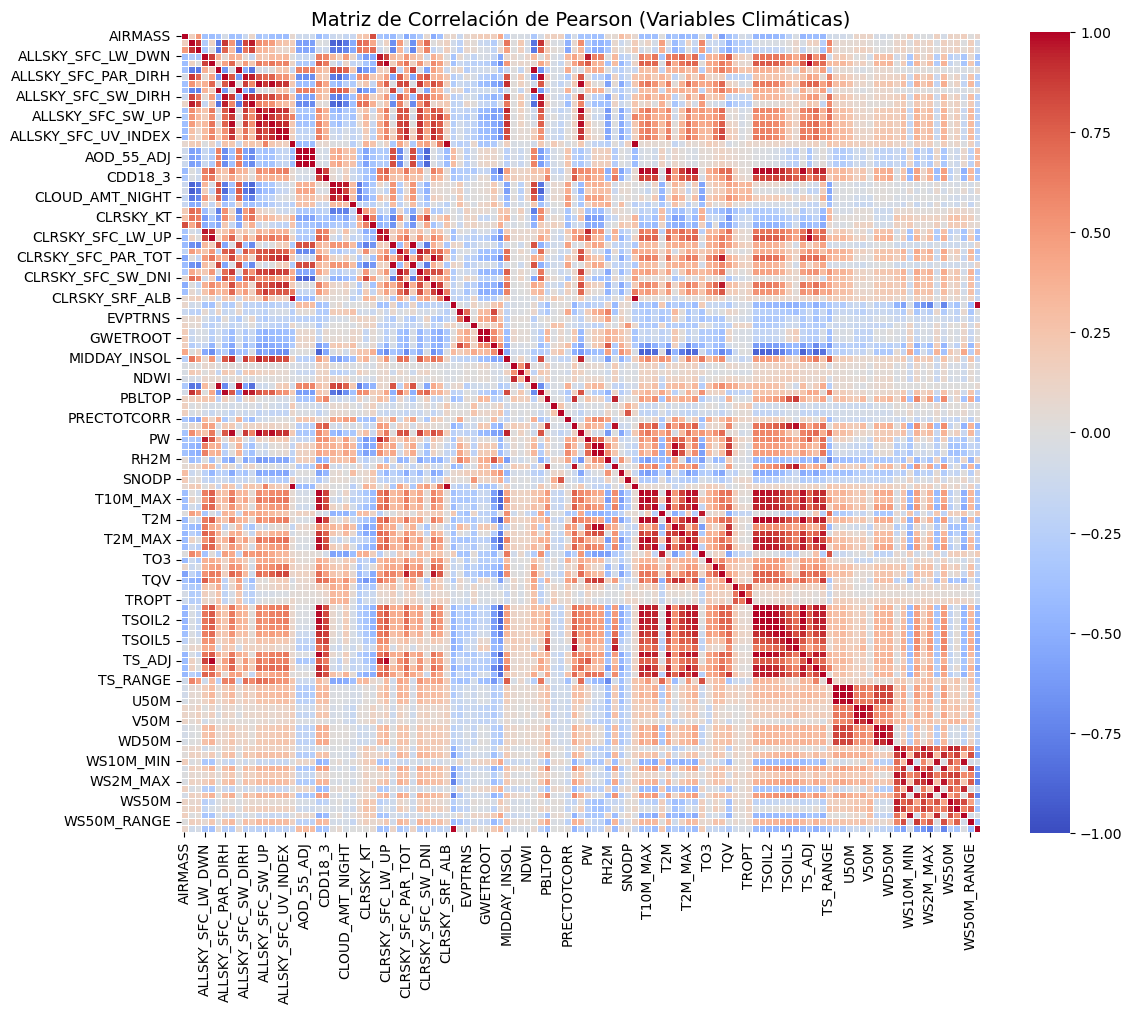

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt


# Calculamos la matriz de correlación de las variables climáticas originales
matriz_corr = df_clima.corr(method='pearson')

fig, ax = plt.subplots(figsize=(12, 10))

# Generamos el Heatmap
sns.heatmap(matriz_corr, 
            cmap='coolwarm',  # Colores: Azul (negativa), Blanco (cero), Rojo (positiva)
            vmin=-1, vmax=1,  # Rango de Pearson
            annot=False,      # Apagamos los números porque son muchas variables
            square=True, 
            linewidths=.5)

ax.set_title('Matriz de Correlación de Pearson (Variables Climáticas)', fontsize=14)
plt.tight_layout()
plt.show()

In [40]:

# Quitar representantes con corr < 0.02
cols_clima_finales = df_log[df_log['corr_target'] >= 0.02]['representante'].tolist()

print(f"Climáticas antes : {len(cols_clima_reducidas)}")
print(f"Climáticas finales: {len(cols_clima_finales)}")

# Columnas no climáticas
cols_no_clima = ['latitud', 'longitud', 'mes', 'dia_semana', 'tipo_de_incendio',
                 'tipo_de_vegetacion', 'regimen_del_fuego', 'nombre_municipio',
                 'pob_total', 'hora_deteccion_min']

ID_COL     = 'id_clave_inc'
TARGET_COL = 'tamanio_modelo'

cols_features = cols_no_clima + cols_clima_finales

# Separar X e y
X_train = train[cols_features].copy()
y_train = train[TARGET_COL]

X_val   = val[cols_features].copy()
y_val   = val[TARGET_COL]

X_test  = test[cols_features].copy()
y_test  = test[TARGET_COL]

print(f"\nX_train : {X_train.shape}")
print(f"X_val   : {X_val.shape}")
print(f"X_test  : {X_test.shape}")

print("\nFeatures listas.")

Climáticas antes : 33
Climáticas finales: 28

X_train : (9743, 38)
X_val   : (920, 38)
X_test  : (1866, 38)

Features listas.


In [41]:
from sklearn.preprocessing import OrdinalEncoder

# ================================================================
# ENCODING DE CATEGÓRICAS
# ================================================================

cols_categoricas = ['tipo_de_incendio', 'tipo_de_vegetacion',
                    'regimen_del_fuego', 'nombre_municipio']

enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

# Aprender solo del train
X_train[cols_categoricas] = enc.fit_transform(X_train[cols_categoricas])

# Aplicar a val y test sin reajustar
X_val[cols_categoricas]   = enc.transform(X_val[cols_categoricas])
X_test[cols_categoricas]  = enc.transform(X_test[cols_categoricas])

print("Tipos de datos después del encoding:")
print(X_train.dtypes.value_counts())
print("\nEncoding listo.")

Tipos de datos después del encoding:
float64    34
float32     2
int32       2
Name: count, dtype: int64

Encoding listo.


Modelo entrenado.

--- Validación ---
              precision    recall  f1-score   support

     1_0_a_5       0.67      0.97      0.80       602
    2_6_a_20       0.18      0.03      0.05       196
   3_21_a_50       0.00      0.00      0.00        61
 4_mas_de_50       0.36      0.08      0.13        61

    accuracy                           0.65       920
   macro avg       0.30      0.27      0.25       920
weighted avg       0.50      0.65      0.54       920



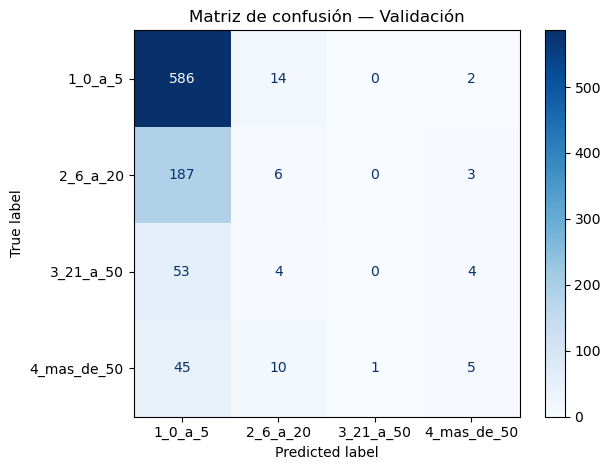

In [42]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

clf = RandomForestClassifier(
    n_estimators    = 300,
    max_depth       = None,
    min_samples_leaf= 5,
    class_weight    = 'balanced',
    random_state    = 42,
    n_jobs          = -1
)

clf.fit(X_train, y_train)
print("Modelo entrenado.")

y_pred_val = clf.predict(X_val)

print("\n--- Validación ---")
print(classification_report(y_val, y_pred_val))

cm  = confusion_matrix(y_val, y_pred_val, labels=clf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot(cmap='Blues')
plt.title('Matriz de confusión — Validación')
plt.tight_layout()
plt.show()

/tmp/ipykernel_6331/22513978.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


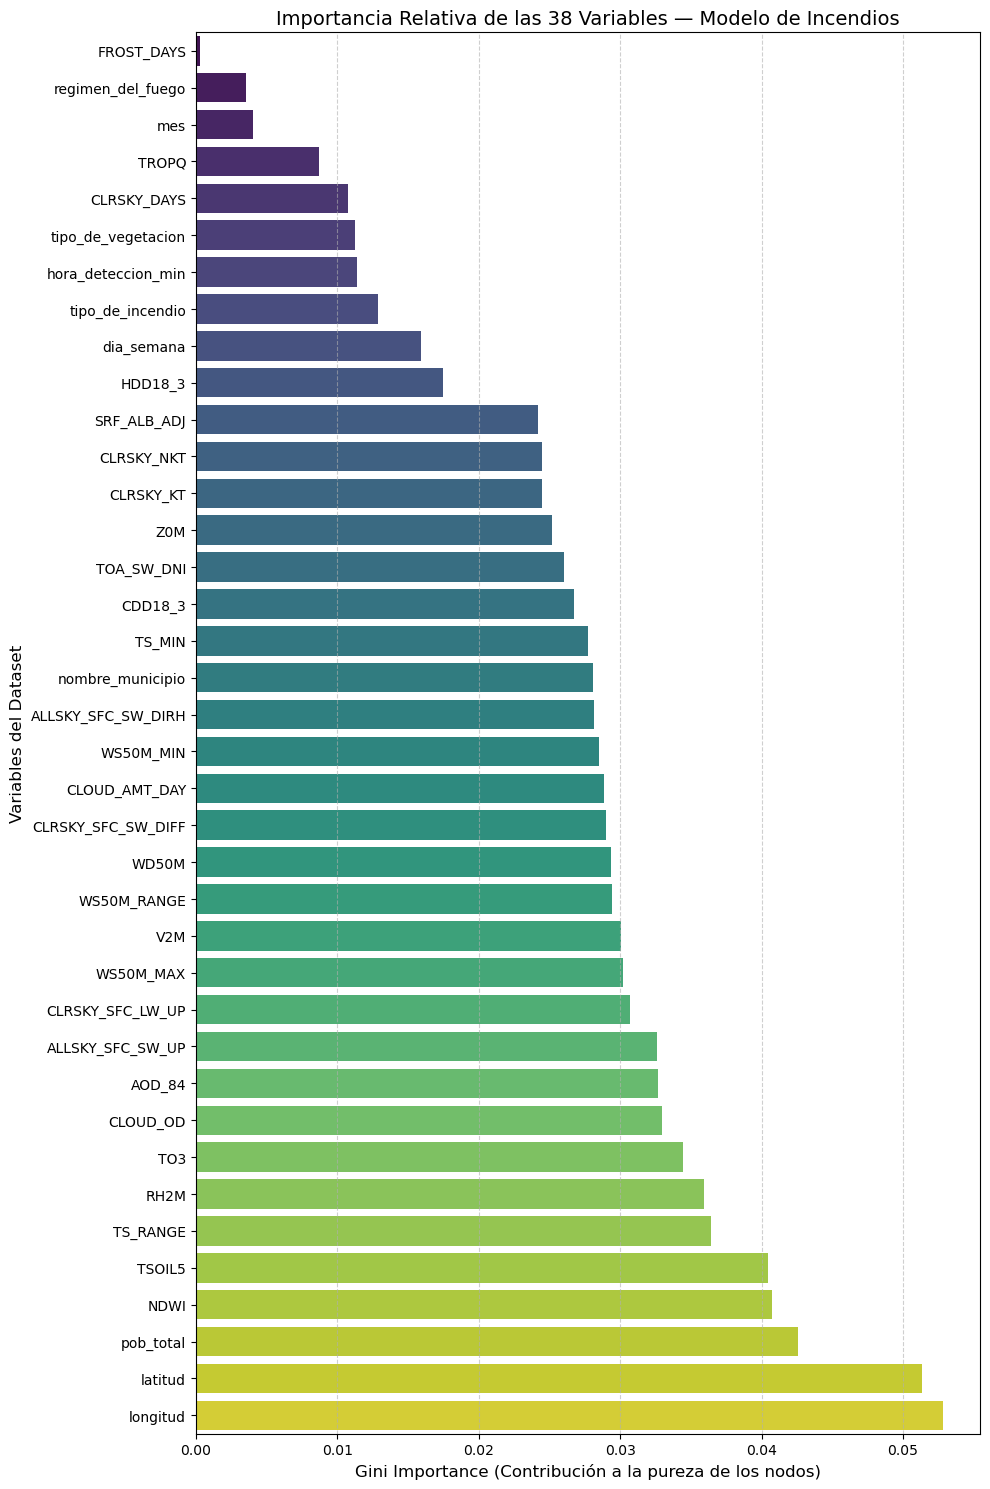


--- Listado Completo de Importancias ---
              Variable  Importancia
1             longitud     0.052799
0              latitud     0.051365
8            pob_total     0.042571
30                NDWI     0.040764
11              TSOIL5     0.040418
15            TS_RANGE     0.036388
12                RH2M     0.035915
18                 TO3     0.034424
16            CLOUD_OD     0.032931
29              AOD_84     0.032653
13    ALLSKY_SFC_SW_UP     0.032572
20    CLRSKY_SFC_LW_UP     0.030665
31           WS50M_MAX     0.030218
26                 V2M     0.030053
19         WS50M_RANGE     0.029390
28               WD50M     0.029321
25  CLRSKY_SFC_SW_DIFF     0.028985
27       CLOUD_AMT_DAY     0.028852
23           WS50M_MIN     0.028485
24  ALLSKY_SFC_SW_DIRH     0.028124
7     nombre_municipio     0.028042
14              TS_MIN     0.027737
10             CDD18_3     0.026699
22          TOA_SW_DNI     0.026026
32                 Z0M     0.025144
36           CLRSKY_KT

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

importances = clf.feature_importances_
feature_names = X_train.columns

# 2. Crear un DataFrame ordenado
df_importance = pd.DataFrame({
    'Variable': feature_names,
    'Importancia': importances
}).sort_values(by='Importancia', ascending=True) 

plt.figure(figsize=(10, 15)) 

sns.barplot(
    x='Importancia', 
    y='Variable', 
    data=df_importance, 
    palette='viridis'
)

plt.title('Importancia Relativa de las 38 Variables — Modelo de Incendios', fontsize=14)
plt.xlabel('Gini Importance (Contribución a la pureza de los nodos)', fontsize=12)
plt.ylabel('Variables del Dataset', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# 4. Mostrar la tabla completa en consola por si necesitas los valores exactos
pd.set_option('display.max_rows', None) 
print("\n--- Listado Completo de Importancias ---")
print(df_importance.sort_values(by='Importancia', ascending=False))

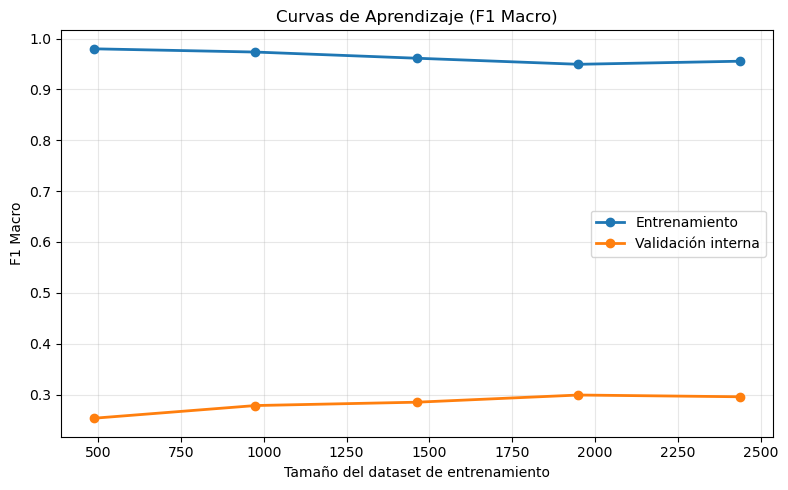

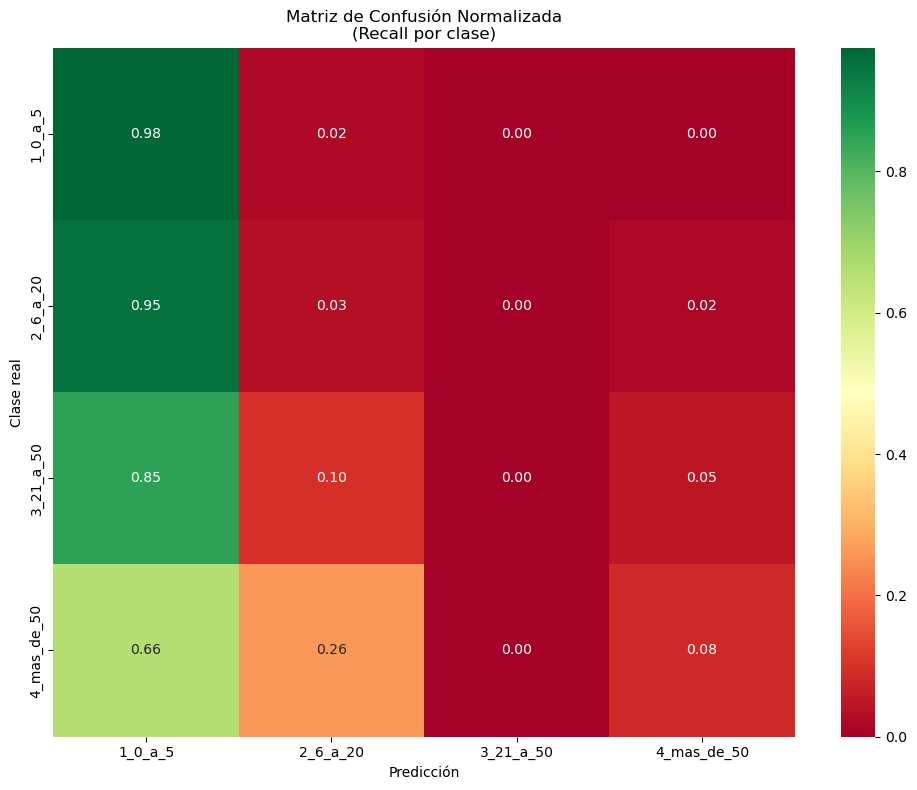

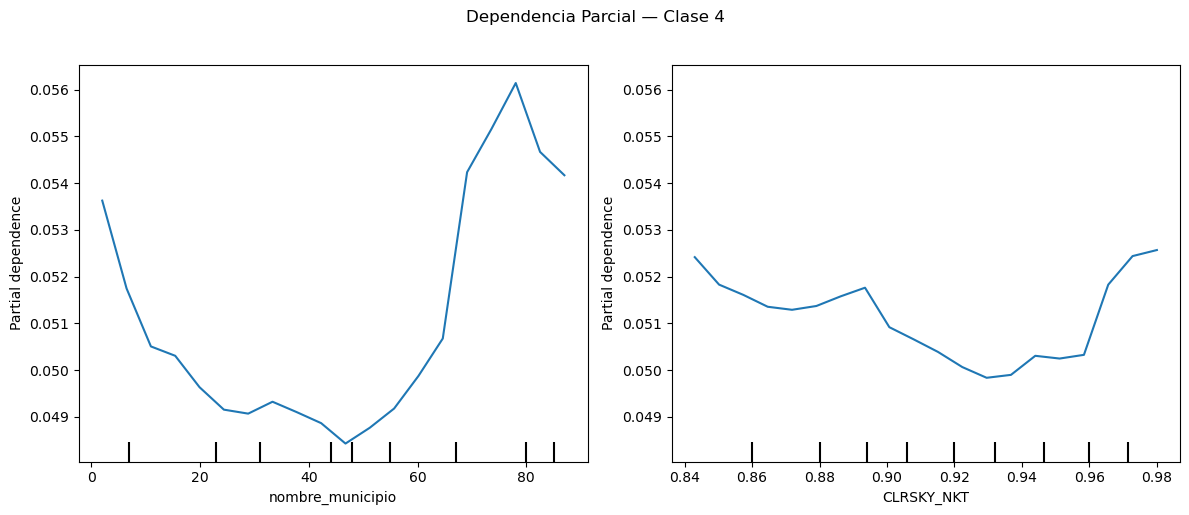

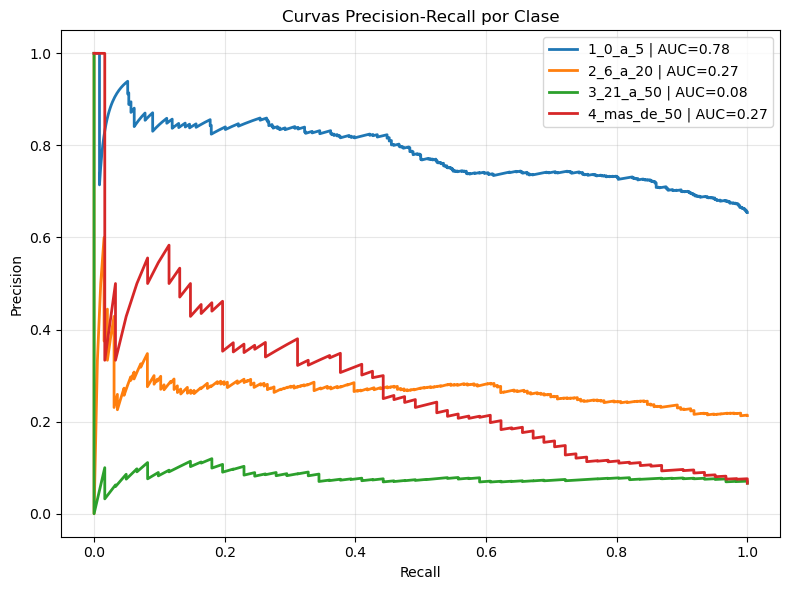

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import learning_curve
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import auc
from sklearn.inspection import PartialDependenceDisplay


# ============================================================
# 1) CURVA DE APRENDIZAJE
# ============================================================
def plot_learning_curve(clf, X_train, y_train):

    # respetar temporalidad
    tscv = TimeSeriesSplit(n_splits=3)

    train_sizes, train_scores, val_scores = learning_curve(
        estimator=clf,
        X=X_train,
        y=y_train,
        cv=tscv,
        n_jobs=-1,
        train_sizes=np.linspace(0.2, 1.0, 5),
        scoring='f1_macro'
    )

    train_mean = train_scores.mean(axis=1)
    val_mean   = val_scores.mean(axis=1)

    fig, ax = plt.subplots(figsize=(8, 5))

    ax.plot(
        train_sizes,
        train_mean,
        marker='o',
        linewidth=2,
        label='Entrenamiento'
    )

    ax.plot(
        train_sizes,
        val_mean,
        marker='o',
        linewidth=2,
        label='Validación interna'
    )

    ax.set_title('Curvas de Aprendizaje (F1 Macro)')
    ax.set_xlabel('Tamaño del dataset de entrenamiento')
    ax.set_ylabel('F1 Macro')
    ax.grid(alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.show()


# ============================================================
# 2) MATRIZ NORMALIZADA
# ============================================================
def plot_normalized_cm(clf, X_val, y_val):

    y_pred = clf.predict(X_val)

    cm = confusion_matrix(
        y_val,
        y_pred,
        labels=clf.classes_
    )

    # normalizar por fila
    row_sum = cm.sum(axis=1, keepdims=True)
    row_sum[row_sum == 0] = 1

    cm_norm = cm / row_sum

    fig, ax = plt.subplots(figsize=(10, 8))

    sns.heatmap(
        cm_norm,
        annot=True,
        fmt='.2f',
        cmap='RdYlGn',
        xticklabels=clf.classes_,
        yticklabels=clf.classes_,
        ax=ax
    )

    ax.set_title(
        'Matriz de Confusión Normalizada\n(Recall por clase)'
    )
    ax.set_ylabel('Clase real')
    ax.set_xlabel('Predicción')

    plt.tight_layout()
    plt.show()


# ============================================================
# 3) PDP
# ============================================================
def plot_pdp(clf, X_train, features_to_plot):

    features_validas = [
        c for c in features_to_plot
        if c in X_train.columns
    ]

    if len(features_validas) == 0:
        print("No hay variables válidas para PDP.")
        return

    fig, ax = plt.subplots(
        figsize=(12, 5),
        ncols=len(features_validas)
    )

    PartialDependenceDisplay.from_estimator(
        estimator=clf,
        X=X_train,
        features=features_validas,
        target='4_mas_de_50',
        grid_resolution=20,
        ax=ax
    )

    plt.suptitle(
        'Dependencia Parcial — Clase 4',
        y=1.02
    )

    plt.tight_layout()
    plt.show()


# ============================================================
# 4) PRECISION-RECALL
# ============================================================
def plot_multiclass_precision_recall(clf, X_val, y_val):

    y_score = clf.predict_proba(X_val)

    fig, ax = plt.subplots(figsize=(8, 6))

    for i, clase in enumerate(clf.classes_):

        y_true_bin = (y_val == clase).astype(int)

        precision, recall, _ = precision_recall_curve(
            y_true_bin,
            y_score[:, i]
        )

        pr_auc = auc(recall, precision)

        ax.plot(
            recall,
            precision,
            linewidth=2,
            label=f'{clase} | AUC={pr_auc:.2f}'
        )

    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title('Curvas Precision-Recall por Clase')
    ax.grid(alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.show()


# ============================================================
# EJECUCIÓN
# ============================================================

# 1) Curva aprendizaje
plot_learning_curve(clf, X_train, y_train)

# 2) Matriz normalizada (2023)
plot_normalized_cm(clf, X_val, y_val)

# 3) PDP
plot_pdp(
    clf,
    X_train,
    ['nombre_municipio', 'CLRSKY_NKT']
)

# 4) Precision-Recall
plot_multiclass_precision_recall(
    clf,
    X_val,
    y_val
)

# Experimento 2

In [44]:
import sys, os, duckdb
import pandas as pd

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
from config.config import V2_DB

con = duckdb.connect(V2_DB)

# ==============================================================================
# 0. VARIABLES DESCARTADAS (El filtro de entrada)
# ==============================================================================
VARS_DESCARTADAS = (
    'CLOUD_BT', 'CLOUD_BT_MAX', 'CLOUD_BT_MIN',
    'CLOUD_TT', 'CLOUD_TT_MAX', 'CLOUD_TT_MIN',
    'GWM_HEIGHT', 'GWM_HEIGHT_ANOMALY',
    'IMERG_PRECLIQUID_PROB', 'IMERG_PRECTOT', 'IMERG_PRECTOT_COUNT',
    'LWLAND', 'ORIGINAL_ALLSKY_SFC_LW_DWN', 'ORIGINAL_ALLSKY_SFC_SW_DWN',
    'ORIGINAL_CLRSKY_SFC_LW_DWN', 'ORIGINAL_CLRSKY_SFC_SW_DWN',
    'PRMC', 'PRMC_PRCNTL', 'RZMC', 'RZMC_PRCNTL',
    'SFMC', 'SWLAND', 'SZA'
)
vars_excluidas_sql = ", ".join([f"'{v}'" for v in VARS_DESCARTADAS])

# ==============================================================================
# 1. CARGA Y CLASIFICACIÓN INTELIGENTE (Solo variables válidas)
# ==============================================================================
# Filtramos el diccionario desde el inicio
df_diccionario = con.execute(f"""
    SELECT id_variable, fuente, nombre_completo 
    FROM working.diccionario 
    WHERE id_variable NOT IN ({vars_excluidas_sql})
""").df()

pivot_statements = []

for _, row in df_diccionario.iterrows():
    vid = row['id_variable']
    fuente = str(row['fuente']).lower()
    nombre = str(row['nombre_completo']).lower()
    
    base_case = f"CASE WHEN id_variable = '{vid}' THEN resultado_numerico END"
    
    if 'google' in fuente:
        pivot_statements.append(f"MAX({base_case}) AS \"{vid}\"")
    elif any(k in nombre for k in ['precipitation', 'precip', 'snow', 'rain']):
        pivot_statements.append(f"SUM({base_case}) AS \"{vid}_SUM\"")
    elif any(k in nombre for k in ['humidity', 'wetness', 'moisture']):
        pivot_statements.append(f"MIN({base_case}) AS \"{vid}_MIN\"")
    elif any(k in nombre for k in ['wind', 'speed']):
        pivot_statements.append(f"MAX({base_case}) AS \"{vid}_MAX\"")
        pivot_statements.append(f"STDDEV({base_case}) AS \"{vid}_STD\"")
    elif any(k in nombre for k in ['temperature', 'irradiance', 'insolation', 'solar', 'thermal', 'albedo', 'par', 'cdd']):
        pivot_statements.append(f"MAX({base_case}) AS \"{vid}_MAX\"")
    else:
        pivot_statements.append(f"MEDIAN({base_case}) AS \"{vid}_MEDIAN\"")

pivot_cols = ",\n    ".join(pivot_statements)

# ==============================================================================
# 2. EXTRACCIÓN CON DUCKDB (Filtrando variables descartadas para optimizar RAM)
# ==============================================================================
df = con.execute(f"""
    WITH clima_pivot AS (
        SELECT
            id_clave_inc,
            {pivot_cols}
        FROM working.climatologia
        WHERE id_variable NOT IN ({vars_excluidas_sql})
        GROUP BY id_clave_inc
    ),
    demo_total AS (
        SELECT
            id_cvegeo,
            anio,
            SUM(pob_total) AS pob_total
        FROM working.demografia
        GROUP BY id_cvegeo, anio
    )
    SELECT
        i.id_clave_inc,
        i.latitud,
        i.longitud,
        i.anio,
        EXTRACT(MONTH FROM i.fecha_inicio)::INTEGER AS mes,
        EXTRACT(DOW   FROM i.fecha_inicio)::INTEGER AS dia_semana,
        i.tipo_de_incendio,
        v.tipo_de_vegetacion,
        v.regimen_del_fuego,
        o.hora_deteccion,
        dem.pob_total,
        d.tamanio,
        cp.*
    FROM working.incendios i
    LEFT JOIN working.vegetacion   v   ON i.id_vegetacion = v.id_vegetacion
    LEFT JOIN working.municipios   m   ON i.id_cvegeo     = m.id_cvegeo
    LEFT JOIN working.operaciones  o   ON i.id_clave_inc  = o.id_clave_inc
    LEFT JOIN working.danos        d   ON i.id_clave_inc  = d.id_clave_inc
    LEFT JOIN demo_total           dem ON i.id_cvegeo     = dem.id_cvegeo
                                      AND i.anio          = dem.anio
    LEFT JOIN clima_pivot          cp  ON i.id_clave_inc  = cp.id_clave_inc
""").df()

con.close()

# ==============================================================================
# 3. LIMPIEZA INICIAL
# ==============================================================================
df = df.loc[:, ~df.columns.duplicated()]

df['hora_deteccion'] = pd.to_datetime(df['hora_deteccion'].astype(str), errors='coerce')
df['hora_deteccion_min'] = (df['hora_deteccion'].dt.hour * 60 + df['hora_deteccion'].dt.minute)
df = df.drop(columns=['hora_deteccion'])

print(f"Dimensiones tras extracción: {df.shape}")

# ==============================================================================
# 4. LIMPIEZA QUIRÚRGICA, UNIFICACIÓN Y NULOS
# ==============================================================================
# Eliminar filas sin coordenadas
df_clean = df.dropna(subset=['latitud', 'longitud']).copy()

# Mapeo del Target
mapeo_clases = {
    '0 a 5 hectareas':       '1_0_a_5',
    '6 a 10 hectareas':      '2_6_a_20',
    '11 a 20 hectareas':     '2_6_a_20',
    '21 a 50 hectareas':     '3_21_a_50',
    '51 a 100 hectareas':    '4_mas_de_50',
    'mayor a 100 hectareas': '4_mas_de_50'
}
df_clean['tamanio_modelo'] = df_clean['tamanio'].map(mapeo_clases)

# Eliminar columnas 100% nulas (Fantasmas generadas por variables sin datos)
df_clean = df_clean.dropna(axis=1, how='all')

# Imputar nulos restantes (Suelos antiguos, NDMI) con la mediana
cols_numericas = df_clean.select_dtypes(include=['float64', 'float32', 'int64', 'int32']).columns
df_clean[cols_numericas] = df_clean[cols_numericas].fillna(df_clean[cols_numericas].median())

# Seguridad contra nulos persistentes
df_clean[cols_numericas] = df_clean[cols_numericas].fillna(0)

print(f"Dimensiones finales (listas para el modelo): {df_clean.shape}")
print(f"Total de valores nulos: {df_clean.isnull().sum().sum()}")
print("\n--- Distribución Final del Target ---")
print(df_clean['tamanio_modelo'].value_counts(dropna=False))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Dimensiones tras extracción: (12703, 157)
Dimensiones finales (listas para el modelo): (12529, 157)
Total de valores nulos: 0

--- Distribución Final del Target ---
tamanio_modelo
1_0_a_5        9536
2_6_a_20       2008
3_21_a_50       543
4_mas_de_50     442
Name: count, dtype: int64


/tmp/ipykernel_6331/3314694513.py:112: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['hora_deteccion'] = pd.to_datetime(df['hora_deteccion'].astype(str), errors='coerce')


/tmp/ipykernel_6331/3642937954.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='tamanio_modelo', y=var_calor, data=df_clean,
/tmp/ipykernel_6331/3642937954.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='tamanio_modelo', y=var_humedad, data=df_clean,
/tmp/ipykernel_6331/3642937954.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='tamanio_modelo', y=var_viento, data=df_clean,


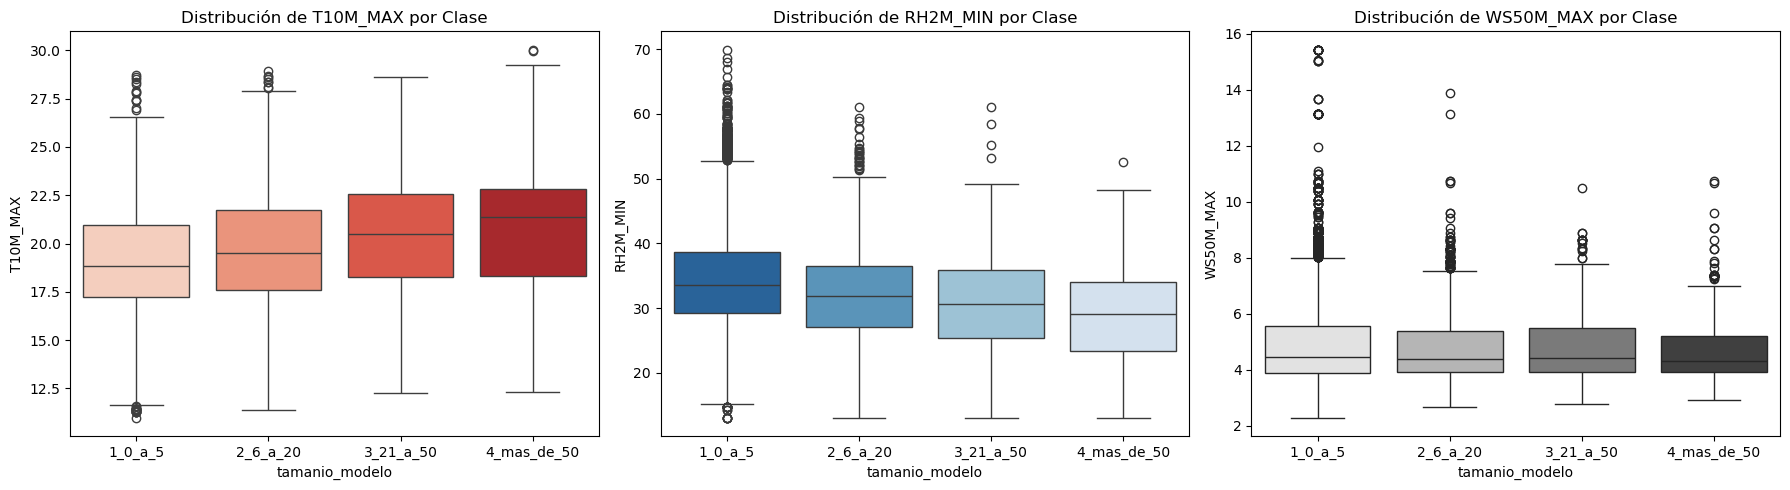

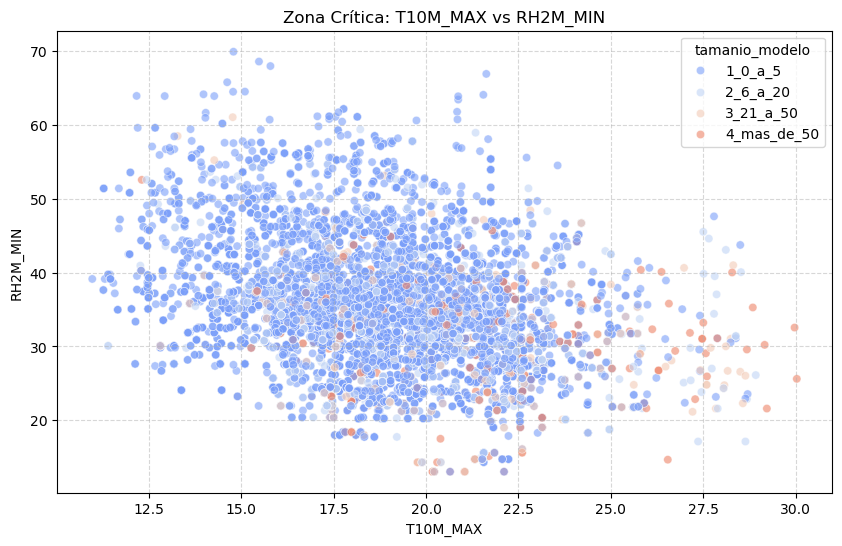

Text(0.5, 1.0, 'Matriz de Correlación - Nuevas Variables Pico')

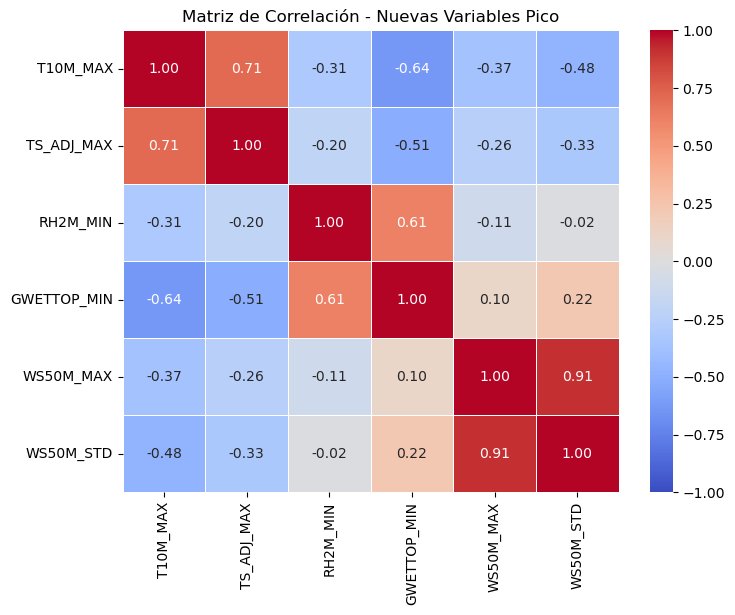

In [51]:

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ==============================================================================
# 1. VISUALIZACIÓN DE SEPARACIÓN DE CLASES (Boxplots y Scatter)
# ==============================================================================
# Nota: Ajusta los nombres de las columnas si en tu DF se llaman ligeramente distinto.
# Usaremos variables representativas que sabemos que salieron del diccionario.

# Elegimos 3 variables críticas de los nuevos grupos
var_calor = 'T10M_MAX'    # El pico de temperatura
var_humedad = 'RH2M_MIN'  # La caída crítica de humedad
var_viento = 'WS50M_MAX'  # Las ráfagas máximas

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1A. Boxplots: ¿Los incendios Clase 4 tienen picos más altos?
sns.boxplot(x='tamanio_modelo', y=var_calor, data=df_clean, 
            order=['1_0_a_5', '2_6_a_20', '3_21_a_50', '4_mas_de_50'], ax=axes[0], palette='Reds')
axes[0].set_title(f'Distribución de {var_calor} por Clase')

sns.boxplot(x='tamanio_modelo', y=var_humedad, data=df_clean, 
            order=['1_0_a_5', '2_6_a_20', '3_21_a_50', '4_mas_de_50'], ax=axes[1], palette='Blues_r')
axes[1].set_title(f'Distribución de {var_humedad} por Clase')

sns.boxplot(x='tamanio_modelo', y=var_viento, data=df_clean, 
            order=['1_0_a_5', '2_6_a_20', '3_21_a_50', '4_mas_de_50'], ax=axes[2], palette='Greys')
axes[2].set_title(f'Distribución de {var_viento} por Clase')

plt.tight_layout()
plt.show()

# 1B. Scatterplot 2D: Buscando la "Zona de Peligro"
plt.figure(figsize=(10, 6))
sns.scatterplot(x=var_calor, y=var_humedad, hue='tamanio_modelo', 
                hue_order=['1_0_a_5', '2_6_a_20', '3_21_a_50', '4_mas_de_50'],
                data=df_clean, alpha=0.6, palette='coolwarm')
plt.title(f'Zona Crítica: {var_calor} vs {var_humedad}')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# ==============================================================================
# 2. VERIFICACIÓN DE MULTICOLINEALIDAD (Matriz de Correlación)
# ==============================================================================
# Evaluar si las métricas derivadas de una misma fuente (o fuentes similares) 
# están diciendo exactamente lo mismo (correlación > 0.90)

# Seleccionamos un grupo de variables nuevas para inspeccionar
cols_a_revisar = [
    'T10M_MAX', 'TS_ADJ_MAX', # Dos medidas de calor
    'RH2M_MIN', 'GWETTOP_MIN', # Dos medidas de sequedad
    'WS50M_MAX', 'WS50M_STD'  # Viento: Ráfaga vs Inestabilidad
]

# Filtrar solo las que realmente existan en el DataFrame para evitar errores
cols_existentes = [c for c in cols_a_revisar if c in df_clean.columns]

plt.figure(figsize=(8, 6))
corr_matrix = df_clean[cols_existentes].corr()

# Mapa de calor
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlación - Nuevas Variables Pico')



In [46]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

TARGET_COL = "tamanio_modelo"

cols_a_excluir = [
    "id_clave_inc",
    "tamanio",
    TARGET_COL
]

if "id_clave_inc_1" in df_clean.columns:
    cols_a_excluir.append("id_clave_inc_1")

# =========================================================
# 1) SPLIT TEMPORAL
# =========================================================
train = df_clean[df_clean["anio"] <= 2022].copy()
val   = df_clean[df_clean["anio"] == 2023].copy()
test  = df_clean[df_clean["anio"] >= 2024].copy()

# =========================================================
# 2) X / y
# =========================================================
X_train = train.drop(columns=cols_a_excluir)
y_train = train[TARGET_COL]

X_val = val.drop(columns=cols_a_excluir)
y_val = val[TARGET_COL]

X_test = test.drop(columns=cols_a_excluir)
y_test = test[TARGET_COL]

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

# =========================================================
# 3) ENCODING
# =========================================================
cols_categoricas = [
    "tipo_de_incendio",
    "tipo_de_vegetacion",
    "regimen_del_fuego"
]

enc = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

X_train[cols_categoricas] = enc.fit_transform(
    X_train[cols_categoricas]
)

X_val[cols_categoricas] = enc.transform(
    X_val[cols_categoricas]
)

X_test[cols_categoricas] = enc.transform(
    X_test[cols_categoricas]
)

# =========================================================
# 4) MODELO
# =========================================================
clf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=15,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

clf.fit(X_train, y_train)

# =========================================================
# 5) VALIDACIÓN
# =========================================================
y_pred_val = clf.predict(X_val)

print(classification_report(y_val, y_pred_val))

# =========================================================
# 6) TEST FINAL
# =========================================================
y_pred_test = clf.predict(X_test)

print("\nTEST:")
print(classification_report(y_test, y_pred_test))

(9743, 153)
(920, 153)
(1866, 153)
              precision    recall  f1-score   support

     1_0_a_5       0.71      0.76      0.73       602
    2_6_a_20       0.24      0.30      0.27       196
   3_21_a_50       0.00      0.00      0.00        61
 4_mas_de_50       0.26      0.10      0.14        61

    accuracy                           0.57       920
   macro avg       0.30      0.29      0.29       920
weighted avg       0.53      0.57      0.55       920


TEST:
              precision    recall  f1-score   support

     1_0_a_5       0.64      0.71      0.67      1037
    2_6_a_20       0.24      0.25      0.24       445
   3_21_a_50       0.09      0.03      0.04       190
 4_mas_de_50       0.18      0.19      0.18       194

    accuracy                           0.48      1866
   macro avg       0.29      0.29      0.29      1866
weighted avg       0.44      0.48      0.46      1866




--- REPORTE VALIDACIÓN ---
              precision    recall  f1-score   support

     1_0_a_5       0.71      0.76      0.73       602
    2_6_a_20       0.24      0.30      0.27       196
   3_21_a_50       0.00      0.00      0.00        61
 4_mas_de_50       0.26      0.10      0.14        61

    accuracy                           0.57       920
   macro avg       0.30      0.29      0.29       920
weighted avg       0.53      0.57      0.55       920



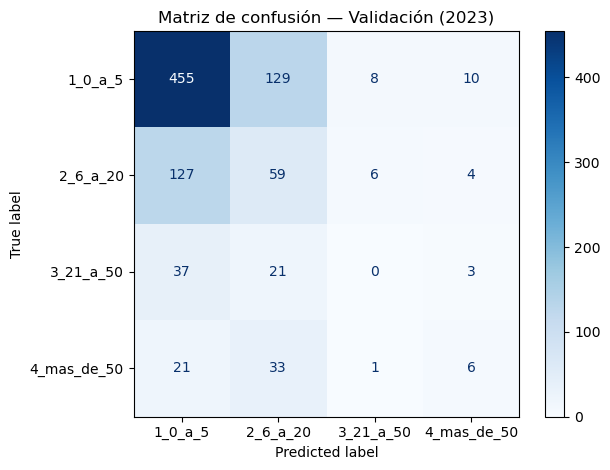


--- REPORTE TEST ---
              precision    recall  f1-score   support

     1_0_a_5       0.64      0.71      0.67      1037
    2_6_a_20       0.24      0.25      0.24       445
   3_21_a_50       0.09      0.03      0.04       190
 4_mas_de_50       0.18      0.19      0.18       194

    accuracy                           0.48      1866
   macro avg       0.29      0.29      0.29      1866
weighted avg       0.44      0.48      0.46      1866



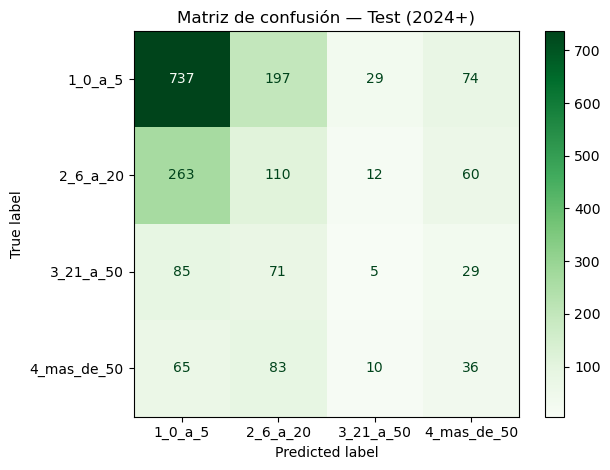

In [47]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# =========================================================
# VALIDACIÓN
# =========================================================
y_pred_val = clf.predict(X_val)

print("\n--- REPORTE VALIDACIÓN ---")
print(classification_report(y_val, y_pred_val))

cm_val = confusion_matrix(
    y_val,
    y_pred_val,
    labels=clf.classes_
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_val,
    display_labels=clf.classes_
)

disp.plot(cmap="Blues")
plt.title("Matriz de confusión — Validación (2023)")
plt.tight_layout()
plt.show()


# =========================================================
# TEST FINAL
# =========================================================
y_pred_test = clf.predict(X_test)

print("\n--- REPORTE TEST ---")
print(classification_report(y_test, y_pred_test))

cm_test = confusion_matrix(
    y_test,
    y_pred_test,
    labels=clf.classes_
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_test,
    display_labels=clf.classes_
)

disp.plot(cmap="Greens")
plt.title("Matriz de confusión — Test (2024+)")
plt.tight_layout()
plt.show()


--- TOP 25 VARIABLES MÁS IMPORTANTES ---
         Variable  Importancia
         longitud     0.019763
          latitud     0.019741
        pob_total     0.019585
   EVPTRNS_MEDIAN     0.014849
             anio     0.014251
       TSOIL6_MAX     0.014002
             NDWI     0.013114
             NDMI     0.013061
           PW_SUM     0.012213
             NDVI     0.012051
       TSOIL5_MAX     0.011755
  CLOUD_OD_MEDIAN     0.010469
       TO3_MEDIAN     0.010196
    EVLAND_MEDIAN     0.010175
    AOD_55_MEDIAN     0.009558
        PS_MEDIAN     0.009529
         WS2M_STD     0.009521
       TS_MAX_MAX     0.009337
          U2M_STD     0.009252
    PBLTOP_MEDIAN     0.009154
      T2M_MAX_MAX     0.009071
         RH2M_MIN     0.008952
    WS10M_MAX_STD     0.008938
AOD_55_ADJ_MEDIAN     0.008933
         U10M_STD     0.008652


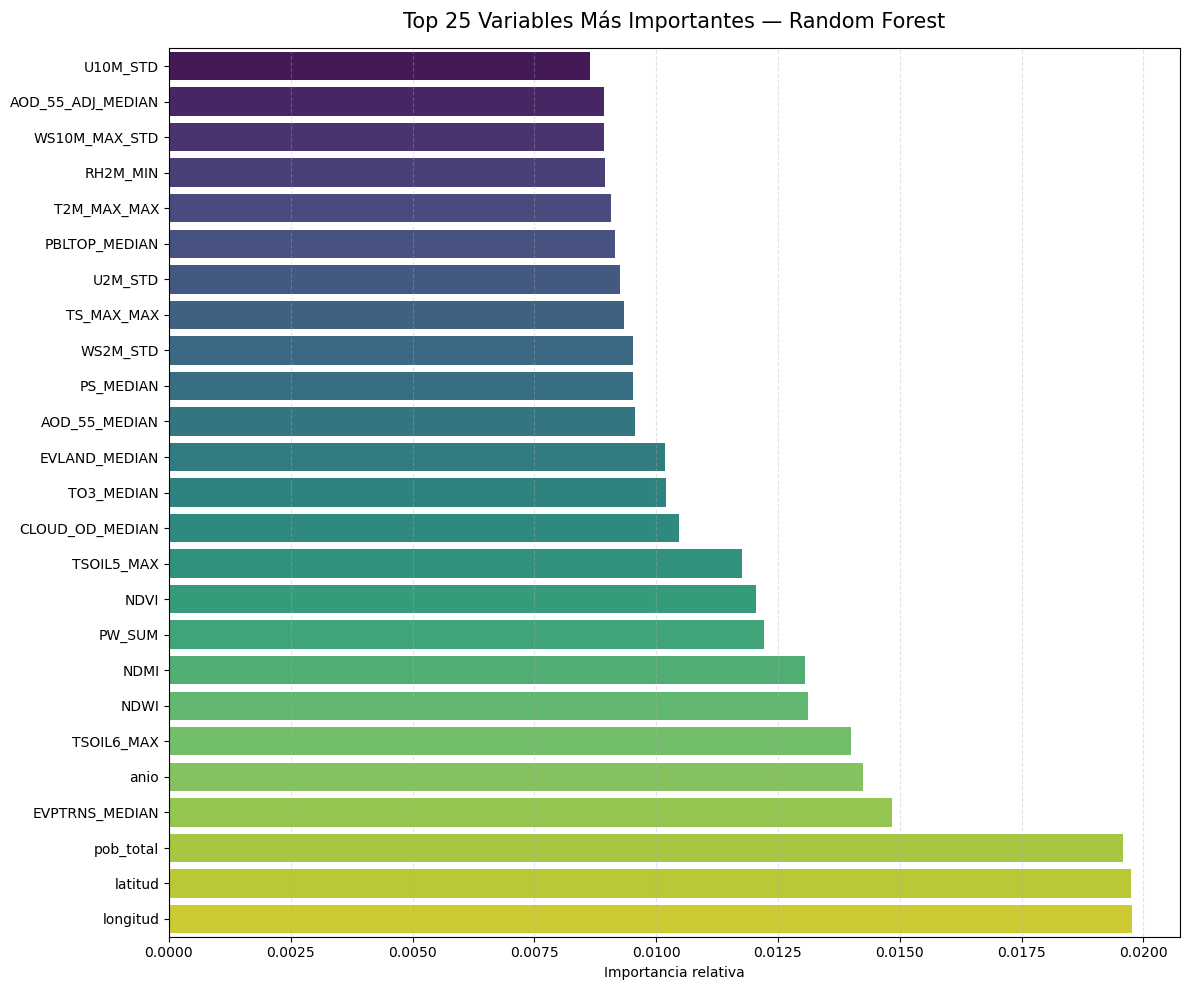

Exception ignored in: <function ResourceTracker.__del__ at 0x7d8ac4581760>
Traceback (most recent call last):
  File "/home/saul/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/saul/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/saul/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes


In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ================================================================
# FEATURE IMPORTANCE — RANDOM FOREST
# ================================================================

# 1) Extraer importancias
importancias = clf.feature_importances_

# 2) Nombres de variables
nombres_features = X_train.columns.tolist()

# 3) DataFrame ordenado
df_importancias = (
    pd.DataFrame({
        "Variable": nombres_features,
        "Importancia": importancias
    })
    .sort_values("Importancia", ascending=False)
    .reset_index(drop=True)
)

# 4) Mostrar top 25
print("\n--- TOP 25 VARIABLES MÁS IMPORTANTES ---")
print(df_importancias.head(25).to_string(index=False))

# ================================================================
# GRÁFICA
# ================================================================
top_n = 25
df_top = df_importancias.head(top_n).iloc[::-1]  # invertir para mejor lectura

fig, ax = plt.subplots(figsize=(12, 10))

sns.barplot(
    data=df_top,
    x="Importancia",
    y="Variable",
    hue="Variable",      # evita warning de seaborn
    palette="viridis",
    dodge=False,
    legend=False,
    ax=ax
)

ax.set_title(
    "Top 25 Variables Más Importantes — Random Forest",
    fontsize=15,
    pad=15
)

ax.set_xlabel("Importancia relativa")
ax.set_ylabel("")
ax.grid(axis="x", linestyle="--", alpha=0.35)

plt.tight_layout()
plt.show()

1/5 Calculando Curva de Aprendizaje...


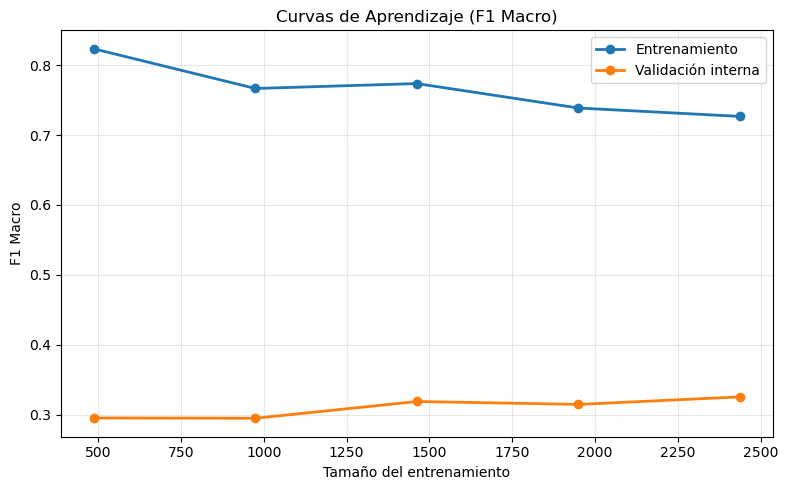

2/5 Generando Matriz de Confusión...


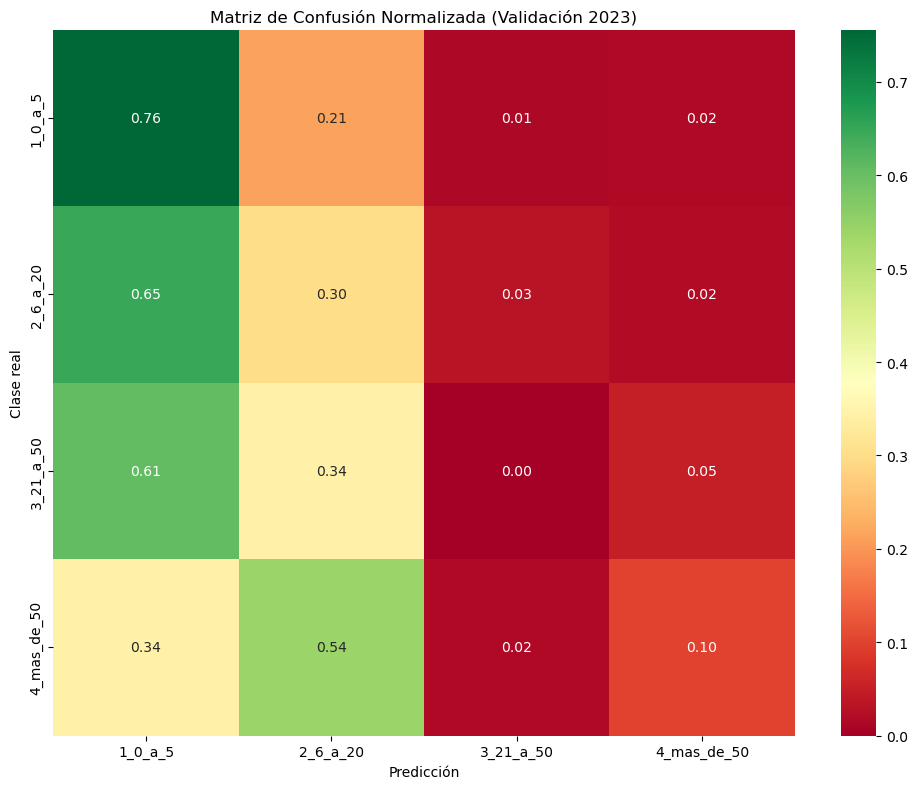

3/5 Analizando importancia de variables...


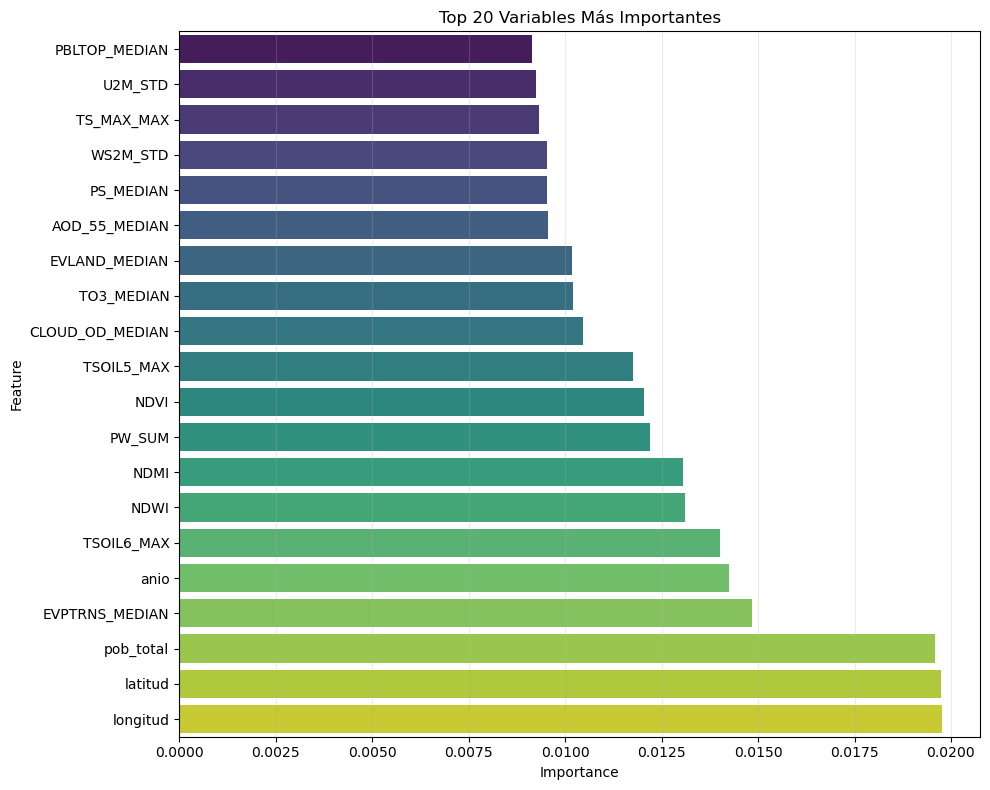

4/5 Calculando PDP...


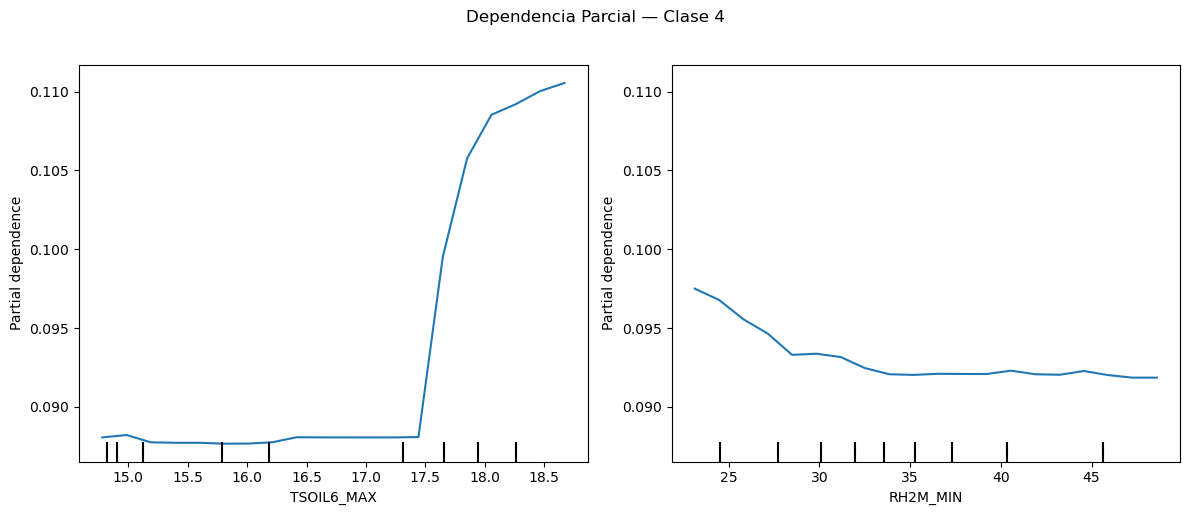

5/5 Analizando falsos negativos...

--- REPORTE ---
Clase 4 clasificados como clase 1: 21

Promedio Validación:
TSOIL6_MAX        16.791273
RH2M_MIN          35.663120
pob_total     168271.235870
dtype: float64

Promedio Falsos Negativos:
TSOIL6_MAX        16.702856
RH2M_MIN          35.759045
pob_total     189184.904762
dtype: float64
6/6 Curvas Precision-Recall...


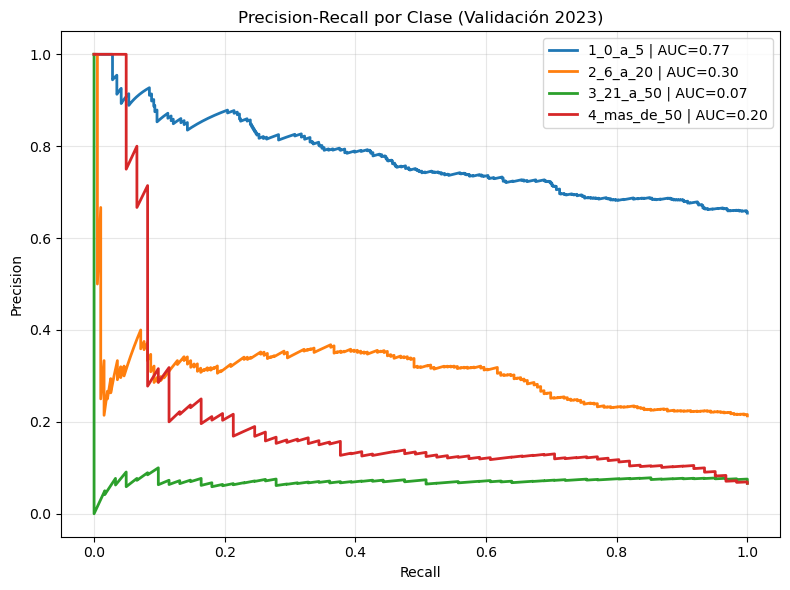

Exception ignored in: <function ResourceTracker.__del__ at 0x7df8b9b91760>
Traceback (most recent call last):
  File "/home/saul/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/saul/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/saul/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x7b185cf95760>
Traceback (most recent call last):
  File "/home/saul/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/saul/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/saul/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x7

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import learning_curve
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import auc
from sklearn.inspection import PartialDependenceDisplay


# ============================================================
# PREDICCIÓN SOBRE VALIDACIÓN (2023)
# ============================================================
y_pred_val = clf.predict(X_val)


# ============================================================
# 1) CURVA DE APRENDIZAJE
# ============================================================
print("1/5 Calculando Curva de Aprendizaje...")

tscv = TimeSeriesSplit(n_splits=3)

train_sizes, train_scores, val_scores = learning_curve(
    estimator=clf,
    X=X_train,
    y=y_train,
    cv=tscv,
    n_jobs=-1,
    scoring="f1_macro",
    train_sizes=np.linspace(0.2, 1.0, 5)
)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    train_sizes,
    train_scores.mean(axis=1),
    marker="o",
    linewidth=2,
    label="Entrenamiento"
)

ax.plot(
    train_sizes,
    val_scores.mean(axis=1),
    marker="o",
    linewidth=2,
    label="Validación interna"
)

ax.set_title("Curvas de Aprendizaje (F1 Macro)")
ax.set_xlabel("Tamaño del entrenamiento")
ax.set_ylabel("F1 Macro")
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()


# ============================================================
# 2) MATRIZ NORMALIZADA
# ============================================================
print("2/5 Generando Matriz de Confusión...")

cm = confusion_matrix(
    y_val,
    y_pred_val,
    labels=clf.classes_
)

row_sum = cm.sum(axis=1, keepdims=True)
row_sum[row_sum == 0] = 1
cm_norm = cm / row_sum

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    xticklabels=clf.classes_,
    yticklabels=clf.classes_,
    ax=ax
)

ax.set_title(
    "Matriz de Confusión Normalizada (Validación 2023)"
)
ax.set_ylabel("Clase real")
ax.set_xlabel("Predicción")

plt.tight_layout()
plt.show()


# ============================================================
# 3) FEATURE IMPORTANCE
# ============================================================
print("3/5 Analizando importancia de variables...")

df_importancias = (
    pd.DataFrame({
        "Feature": X_train.columns,
        "Importance": clf.feature_importances_
    })
    .sort_values("Importance", ascending=False)
)

top20 = df_importancias.head(20).iloc[::-1]

fig, ax = plt.subplots(figsize=(10, 8))

sns.barplot(
    data=top20,
    x="Importance",
    y="Feature",
    hue="Feature",
    dodge=False,
    legend=False,
    palette="viridis",
    ax=ax
)

ax.set_title("Top 20 Variables Más Importantes")
ax.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()


# ============================================================
# 4) PDP
# ============================================================
print("4/5 Calculando PDP...")

features_to_plot = [
    c for c in ["TSOIL6_MAX", "RH2M_MIN"]
    if c in X_train.columns
]

if len(features_to_plot):

    fig, ax = plt.subplots(
        figsize=(12, 5),
        ncols=len(features_to_plot)
    )

    PartialDependenceDisplay.from_estimator(
        estimator=clf,
        X=X_train,
        features=features_to_plot,
        target="4_mas_de_50",
        grid_resolution=20,
        ax=ax
    )

    plt.suptitle(
        "Dependencia Parcial — Clase 4",
        y=1.02
    )

    plt.tight_layout()
    plt.show()

else:
    print("Variables PDP no encontradas.")


# ============================================================
# 5) AUTOPSIA DE FALSOS NEGATIVOS
# ============================================================
print("5/5 Analizando falsos negativos...")

df_val_analysis = X_val.copy()
df_val_analysis["Real"] = y_val.values
df_val_analysis["Pred"] = y_pred_val

falsos_negativos = df_val_analysis[
    (df_val_analysis["Real"] == "4_mas_de_50") &
    (df_val_analysis["Pred"] == "1_0_a_5")
]

print("\n--- REPORTE ---")
print(
    f"Clase 4 clasificados como clase 1: "
    f"{len(falsos_negativos)}"
)

variables_criticas = [
    c for c in ["TSOIL6_MAX", "RH2M_MIN", "pob_total"]
    if c in X_val.columns
]

if variables_criticas:

    print("\nPromedio Validación:")
    print(X_val[variables_criticas].mean())

    print("\nPromedio Falsos Negativos:")

    if not falsos_negativos.empty:
        print(
            falsos_negativos[variables_criticas].mean()
        )
    else:
        print("No hubo falsos negativos críticos.")


# ============================================================
# 6) PRECISION-RECALL
# ============================================================
print("6/6 Curvas Precision-Recall...")

y_score = clf.predict_proba(X_val)

fig, ax = plt.subplots(figsize=(8, 6))

for i, clase in enumerate(clf.classes_):

    y_true_bin = (y_val == clase).astype(int)

    precision, recall, _ = precision_recall_curve(
        y_true_bin,
        y_score[:, i]
    )

    pr_auc = auc(recall, precision)

    ax.plot(
        recall,
        precision,
        linewidth=2,
        label=f"{clase} | AUC={pr_auc:.2f}"
    )

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall por Clase (Validación 2023)")
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
# ¿Ha cambiado la proporción de incendios grandes con el tiempo?
print(df_clean.groupby('anio')['tamanio_modelo'].value_counts(normalize=True).unstack())

tamanio_modelo   1_0_a_5  2_6_a_20  3_21_a_50  4_mas_de_50
anio                                                      
2015            0.908333  0.085417   0.006250          NaN
2016            0.883820  0.102637   0.012117     0.001426
2017            0.843273  0.121359   0.020111     0.015257
2018            0.840146  0.116058   0.032117     0.011679
2019            0.816825  0.137042   0.029172     0.016961
2020            0.758748  0.183241   0.032228     0.025783
2021            0.758389  0.165772   0.041611     0.034228
2022            0.697395  0.200401   0.059118     0.043086
2023            0.654348  0.213043   0.066304     0.066304
2024            0.561567  0.221082   0.100746     0.116604
2025            0.547859  0.261965   0.103275     0.086902
